In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')

In [ ]:
#Fixed the missing values
df = df.dropna()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,150.0,2.3,0.0,0,True,False,...,False,True,True,False,False,False,False,False,False,False
1,2,67,160.0,286.0,108.0,1.5,3.0,2,True,False,...,False,False,False,False,False,True,True,False,True,False
2,3,67,120.0,229.0,129.0,2.6,2.0,1,True,False,...,False,False,False,False,False,True,True,False,False,True
3,4,37,130.0,250.0,187.0,3.5,0.0,0,True,False,...,True,False,False,True,False,False,False,False,True,False
4,5,41,130.0,204.0,172.0,1.4,0.0,0,False,False,...,False,False,False,False,False,False,False,True,True,False


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1], df.iloc[:,-1], test_size=0.2,random_state=2)

- imports the logistic regression algorithm class from the "linear_model" module of scikit-learn.
- LogisticRegression - classification of model (used for prediction categories like YES/NO, 0/1)
- imports the Decision Tree Classifier class from the tree module of scikit-learn.
- Tree based classification model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
 # model initialization (classifier)
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [ ]:
# model training
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier()

In [ ]:
y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy of Logistic Regression",accuracy_score(y_test, y_pred1))
print("Accuracy of DesicionTree", accuracy_score(y_test, y_pred2))

Accuracy of Logistic Regression 0.95
Accuracy of DesicionTree 0.95


In [ ]:
confusion_matrix(y_test, y_pred1)

array([[33,  3],
       [ 0, 24]])

In [ ]:
print("Logistic Regession confusion Matrix : \n")
pd.DataFrame(confusion_matrix(y_test, y_pred1), columns=list(range(0,2)))

Logistic Regession confusion Matrix : 



,0,1
0,33,3
1,0,24


In [ ]:
print("Decision Tree confusion Matrix : \n")
pd.DataFrame(confusion_matrix(y_test, y_pred2), columns=list(range(0,2)))

Decision Tree confusion Matrix : 



,0,1
0,34,2
1,1,23


In [ ]:
result = pd.DataFrame()
result['Actual Label'] = y_test
result['Logistic Regression Predction:'] = y_pred1
result['Desicion Tree pediction :'] = y_pred2

Here we print the table from the sample data and predict it.

In [ ]:
result.sample(10)

,Actual Label,Logistic Regression Predction:,Desicion Tree pediction :
275,True,True,True
209,False,False,False
142,False,False,False
276,False,False,False
128,False,False,False
224,False,False,False
293,True,True,True
65,True,True,True
35,False,False,False
132,False,False,False


In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score

In [ ]:
print("For the Logistic regression Model")
print("-"*50) #separator line
cdf = pd.DataFrame(confusion_matrix(y_test, y_pred1), columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision :", precision_score(y_test, y_pred1))
print("Recall : ", recall_score(y_test, y_pred1))
print("F1 Score", f1_score(y_test, y_pred1))

For the Logistic regression Model
--------------------------------------------------
    0   1
0  33   3
1   0  24
--------------------------------------------------
Precision : 0.8888888888888888
Recall :  1.0
F1 Score 0.9411764705882353


In [ ]:
print("For the DecisionTree")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test, y_pred2), columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision :", precision_score(y_test, y_pred2))
print("Recall :", recall_score(y_test, y_pred2))
print("F1 Score :", f1_score(y_test, y_pred2))

For the DecisionTree
--------------------------------------------------
    0   1
0  34   2
1   1  23
--------------------------------------------------
Precision : 0.92
Recall : 0.9583333333333334
F1 Score : 0.9387755102040817


In [ ]:
# calculates precision for each class separately using scikit-learn.
precision_score(y_test, y_pred1, average = None)

array([1.        , 0.88888889])

In [ ]:
precision_score(y_test, y_pred2, average = None)

array([0.97142857, 0.92      ])

In [ ]:
recall_score(y_test, y_pred1, average = None)

array([0.91666667, 1.        ])

In [ ]:
recall_score(y_test, y_pred2, average = None)

array([0.94444444, 0.95833333])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1], df.iloc[:,-1], test_size=0.2,random_state=2)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_scores = model.predict_proba(X_test)[:,1]

In [ ]:
y_scores

array([0.88452383, 0.05967725, 0.0540862 , 0.11177215, 0.77856964,
       0.02758469, 0.01810549, 0.68950336, 0.64508048, 0.02579498,
       0.77931101, 0.0177239 , 0.05954639, 0.03016959, 0.02701676,
       0.76723847, 0.08798376, 0.90055216, 0.6354682 , 0.02537134,
       0.05634413, 0.76547337, 0.86440899, 0.07394413, 0.01599322,
       0.86532887, 0.05079141, 0.86667697, 0.02959713, 0.15762521,
       0.94570003, 0.04754567, 0.87934187, 0.01979909, 0.03199619,
       0.02229732, 0.83983099, 0.81627017, 0.9273068 , 0.02746843,
       0.01905604, 0.05027931, 0.87959215, 0.0275247 , 0.53332844,
       0.03602598, 0.04130142, 0.04459468, 0.61016781, 0.79302859,
       0.02140313, 0.04161092, 0.77688548, 0.04511715, 0.90603166,
       0.87304217, 0.82435137, 0.77637558, 0.86642387, 0.02830355])

In [ ]:
from sklearn.metrics import roc_curve
fpr , tpr, thresholds = roc_curve(y_test, y_scores)

In [ ]:
thresholds

array([       inf, 0.94570003, 0.77856964, 0.76723847, 0.53332844,
       0.01599322])

In [ ]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

roc_auc = roc_auc_score(y_test, y_scores)

trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

n = 5
indices = np.arange(len(thresholds)) % n == 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

fig = go.Figure(data=data, layout=layout)

fig.show()

In [ ]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.5333284439949016


In [ ]:
corr = df.corr(numeric_only=True)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
# Drop features with |correlation| > 0.85
to_drop = [col for col in upper.columns if any(upper[col].abs() > 0.85)]
df.drop(columns=to_drop, inplace=True)

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)
fig = go.Figure(data=data, layout=layout)

fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



**Topics Covered**
1. **Correlation Analysis** — detecting and removing highly correlated features
2. **Feature Scaling** — StandardScaler vs MinMaxScaler
3. **Handling Imbalanced Data** — SMOTE (Synthetic Minority Over-sampling Technique)
`Dataset:` Heart Disease UCI (synthetic replica for self-contained execution)

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


In [ ]:
df.corr().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.10,-0.07,0.27,0.22,0.12,-0.13,-0.39,0.09,0.21,-0.17,0.27,0.07,-0.23
sex,-0.10,1.00,-0.04,-0.08,-0.20,0.03,-0.06,-0.05,0.14,0.08,-0.03,0.11,0.20,-0.28
cp,-0.07,-0.04,1.00,0.04,-0.08,0.08,0.04,0.31,-0.40,-0.17,0.13,-0.18,-0.16,0.43
trestbps,0.27,-0.08,0.04,1.00,0.13,0.18,-0.12,-0.04,0.06,0.19,-0.12,0.10,0.06,-0.14
chol,0.22,-0.20,-0.08,0.13,1.00,0.03,-0.15,-0.02,0.07,0.06,-0.01,0.07,0.10,-0.10
fbs,0.12,0.03,0.08,0.18,0.03,1.00,-0.10,-0.01,0.05,0.01,-0.06,0.14,-0.04,-0.04
restecg,-0.13,-0.06,0.04,-0.12,-0.15,-0.10,1.00,0.05,-0.07,-0.05,0.09,-0.08,-0.02,0.13
thalach,-0.39,-0.05,0.31,-0.04,-0.02,-0.01,0.05,1.00,-0.38,-0.35,0.40,-0.21,-0.10,0.42
exang,0.09,0.14,-0.40,0.06,0.07,0.05,-0.07,-0.38,1.00,0.31,-0.27,0.11,0.20,-0.44
oldpeak,0.21,0.08,-0.17,0.19,0.06,0.01,-0.05,-0.35,0.31,1.00,-0.58,0.22,0.20,-0.44


 * 1 --> represents positive
 relationship
 * 0 --> No Relationship
 * -1 --> Strong negative relationship

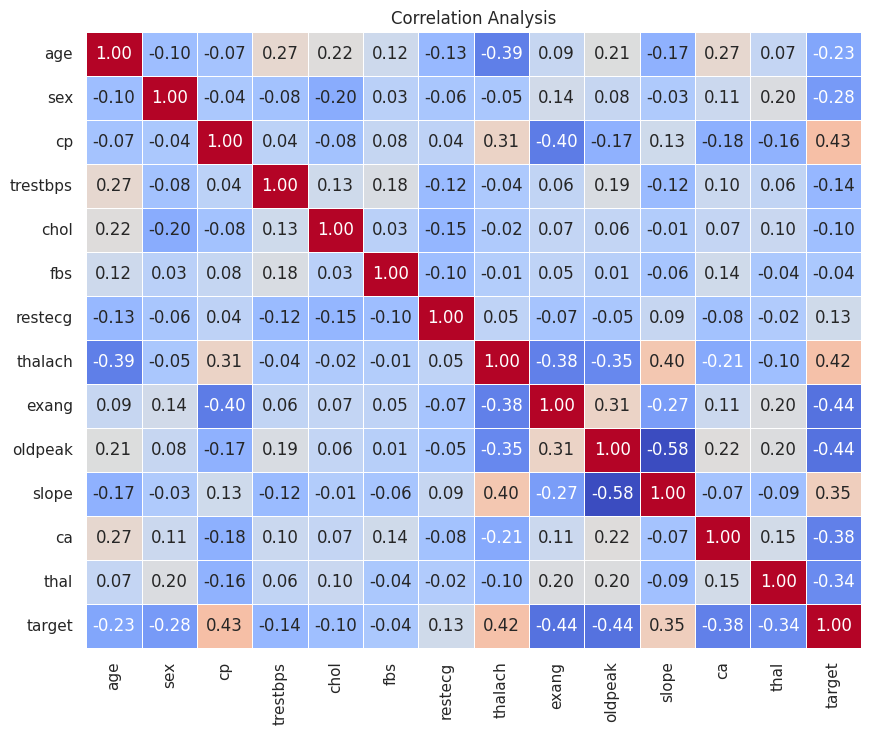

In [ ]:
%matplotlib inline

sns.set(font_scale=1)
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,
    linewidths=0.5,
    fmt='.2f',
    # cmap='YlGnBu',
    cbar=False
)
plt.title("Correlation Analysis")
plt.show()

In [ ]:
df = pd.read_csv('heart.csv')

print('Shape:', df.shape)
print('\nClass distribution (target):')
print(df['target'].value_counts())
print('\nImbalance ratio:', df['target'].value_counts(normalize=True).round(3).to_dict())

df.head()

Shape: (1025, 14)

Class distribution (target):
target
1    526
0    499
Name: count, dtype: int64

Imbalance ratio: {1: 0.513, 0: 0.487}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size :', len(X_train))
print('Test set size     :', len(X_test))

Training set size : 820
Test set size     : 205


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

summay = pd.DataFrame({
    'Raw mean':   X_train.mean(),
    'Raw std':    X_train.std(),
    'Scaled mean': X_train_scaled.mean(),
    'Scaled std':  X_train_scaled.std(),
    'MM mean':    X_train_mm.mean(),
    'MM std':     X_train_mm.std(),
    }).T.round(2)
summay

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
Raw mean,54.61,0.70,0.93,132.35,247.93,0.15,0.51,149.38,0.34,1.08,1.37,0.75,2.34
Raw std,9.11,0.46,1.02,17.97,51.46,0.36,0.52,22.59,0.47,1.18,0.62,1.02,0.61
Scaled mean,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
Scaled std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
MM mean,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41,0.41
MM std,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36,0.36


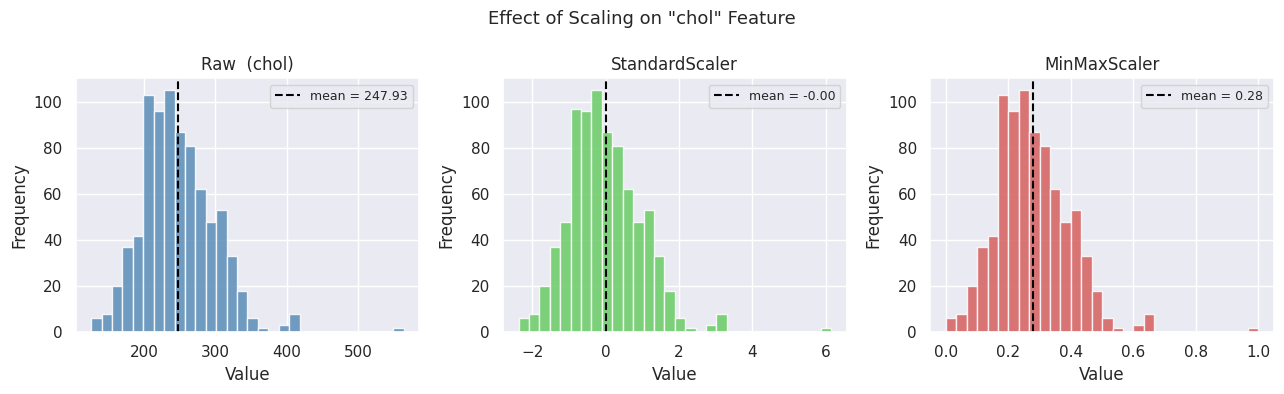

In [ ]:
col_idx = list(X.columns).index('chol')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
data_sets = [
    (X_train['chol'],             'Raw  (chol)',         '#5B8DB8'),
    (X_train_scaled[:, col_idx],     'StandardScaler',      '#6ACC65'),
    (X_train_mm[:, col_idx],      'MinMaxScaler',        '#D65F5F'),
]
for ax, (data, title, color) in zip(axes, data_sets):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(data), color='black', linestyle='--',
               linewidth=1.5, label=f'mean = {np.mean(data):.2f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

fig.suptitle('Effect of Scaling on "chol" Feature', fontsize=13)
plt.tight_layout()
plt.show()

* Handling the Imblanced Data with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE — training class counts:')
print(pd.Series(y_train).value_counts().to_string())

# Apply SMOTE on the already-scaled training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE — training class counts:')
print(pd.Series(y_train_smote).value_counts().to_string())
print(f'\nNew synthetic samples added: {len(X_train_smote) - len(X_train_scaled)}')

Before SMOTE — training class counts:
target
1    421
0    399

After SMOTE — training class counts:
target
0    421
1    421

New synthetic samples added: 22


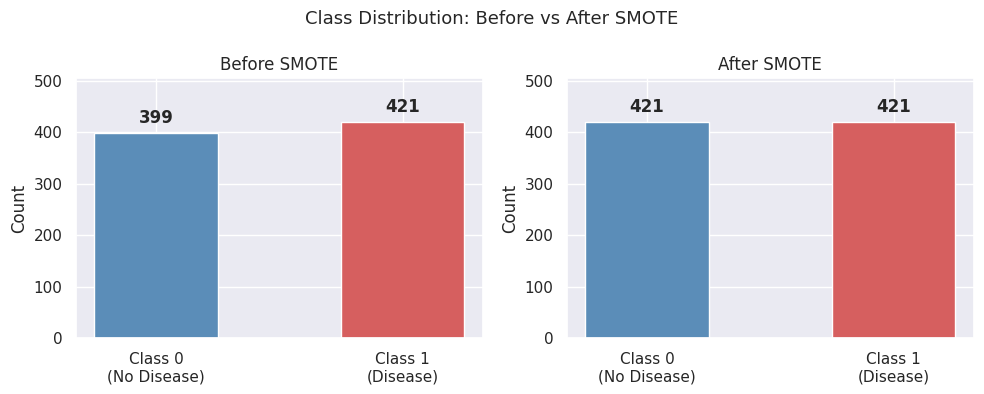

In [ ]:
# bar chart for befoe vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, counts, title in [
    (axes[0], pd.Series(y_train).value_counts().sort_index(),       'Before SMOTE'),
    (axes[1], pd.Series(y_train_smote).value_counts().sort_index(), 'After SMOTE'),
]:
    bars = ax.bar(['Class 0\n(No Disease)', 'Class 1\n(Disease)'],
                  counts.values, color=['#5B8DB8', '#D65F5F'], edgecolor='white', width=0.5)
    ax.set_ylim(0, max(counts.values) * 1.2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    ax.bar_label(bars, padding=4, fontweight='bold')

fig.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()


### Hyperparameter Tuning - Tuning the model using GridSearchCV

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df = pd.read_csv("heart.csv")

df['diagnosis'] = df['target'].apply(lambda x: 'Disease' if x == 1 else 'No Disease')

df[47:150]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,diagnosis
47,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0,No Disease
48,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1,Disease
49,60,1,0,117,230,1,1,160,1,1.4,2,2,3,0,No Disease
50,58,0,3,150,283,1,0,162,0,1.0,2,0,2,1,Disease
51,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,No Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,40,1,0,110,167,0,0,114,1,2.0,1,0,3,0,No Disease
146,51,0,2,120,295,0,0,157,0,0.6,2,0,2,1,Disease
147,41,1,0,110,172,0,0,158,0,0.0,2,0,3,0,No Disease
148,52,1,3,152,298,1,1,178,0,1.2,1,0,3,1,Disease


In [ ]:
df.shape


(1025, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1025 non-null   int64  
 1   sex        1025 non-null   int64  
 2   cp         1025 non-null   int64  
 3   trestbps   1025 non-null   int64  
 4   chol       1025 non-null   int64  
 5   fbs        1025 non-null   int64  
 6   restecg    1025 non-null   int64  
 7   thalach    1025 non-null   int64  
 8   exang      1025 non-null   int64  
 9   oldpeak    1025 non-null   float64
 10  slope      1025 non-null   int64  
 11  ca         1025 non-null   int64  
 12  thal       1025 non-null   int64  
 13  target     1025 non-null   int64  
 14  diagnosis  1025 non-null   object 
dtypes: float64(1), int64(13), object(1)
memory usage: 120.2+ KB


### Prepare Features and Target

In [ ]:
X = df.drop(['target', 'diagnosis'], axis=1)
y = df['target']
print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (1025, 13)
Target distribution:
 target
1    526
0    499
Name: count, dtype: int64


In [ ]:
from sklearn import svm
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = svm.SVC(kernel='rbf', C=30, gamma='auto')
model.fit(X_train, y_train)
model.score(X_test, y_test)

1.0

### K - fold cross Validations

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(svm.SVC(kernel='linear', C=10, gamma='auto'), X, y, cv=5)

array([0.87804878, 0.85853659, 0.83902439, 0.82439024, 0.7804878 ])

In [ ]:
 cross_val_score(svm.SVC(kernel='rbf', C=10, gamma='auto'), X, y, cv=5)

array([1.        , 0.98536585, 0.97073171, 0.98536585, 0.97073171])

In [ ]:
cross_val_score(svm.SVC(kernel='rbf', C=20, gamma='auto'), X, y, cv=5)

array([1.        , 0.98536585, 0.97073171, 0.98536585, 0.97073171])

**Above approach is tiresome and very manual. We can use a for loop as an alternative**

In [ ]:
kernels = ['rbf', 'linear']
C = [1, 10, 20]
avg_scores = {}

for kval in kernels:
    for cval in C:
        cv_scores = cross_val_score(svm.SVC(kernel=kval, C=cval, gamma='auto'), X, y, cv=5)
        avg_scores[kval + '_' + str(cval)] = np.average(cv_scores)

avg_scores

{'rbf_1': np.float64(0.9824390243902439),
 'rbf_10': np.float64(0.9824390243902439),
 'rbf_20': np.float64(0.9824390243902439),
 'linear_1': np.float64(0.8429268292682928),
 'linear_10': np.float64(0.8360975609756098),
 'linear_20': np.float64(0.8321951219512196)}

### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

clf = GridSearchCV(svm.SVC(gamma='auto'), {
    'C': [1, 10, 20],
    'kernel': ['rbf', 'linear']
}, cv=5, return_train_score=False)

clf.fit(X, y)
clf.cv_results_

{'mean_fit_time': array([4.51860428e-02, 4.28643789e+00, 2.23907948e-02, 2.10070639e+01,
        2.02885628e-02, 2.31200817e+01]),
 'std_fit_time': array([1.22588319e-03, 1.06131753e+00, 2.27740405e-03, 7.50199228e+00,
        2.61743409e-04, 6.71117308e+00]),
 'mean_score_time': array([0.01646543, 0.00471764, 0.0078229 , 0.00421743, 0.00718312,
        0.00407305]),
 'std_score_time': array([0.00162387, 0.0005925 , 0.00179109, 0.00013951, 0.00049967,
        0.00011211]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C': 1, 'kernel': 'linear'},
  {'C': 10, 'kernel': 'rbf'},
  {'C': 10, 'kernel': 'linear'},
  {'C': 20, 'kernel': 'rbf'},
 

In [ ]:
df_results = pd.DataFrame(clf.cv_results_)
df_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.045186,0.001226,0.016465,0.001624,1,rbf,"{'C': 1, 'kernel': 'rbf'}",1.000000,0.985366,0.970732,0.985366,0.970732,0.982439,0.010951,1
1,4.286438,1.061318,0.004718,0.000592,1,linear,"{'C': 1, 'kernel': 'linear'}",0.882927,0.868293,0.843902,0.814634,0.804878,0.842927,0.029975,4
2,0.022391,0.002277,0.007823,0.001791,10,rbf,"{'C': 10, 'kernel': 'rbf'}",1.000000,0.985366,0.970732,0.985366,0.970732,0.982439,0.010951,1
3,21.007064,7.501992,0.004217,0.000140,10,linear,"{'C': 10, 'kernel': 'linear'}",0.878049,0.858537,0.839024,0.824390,0.780488,0.836098,0.033171,5
4,0.020289,0.000262,0.007183,0.000500,20,rbf,"{'C': 20, 'kernel': 'rbf'}",1.000000,0.985366,0.970732,0.985366,0.970732,0.982439,0.010951,1
5,23.120082,6.711173,0.004073,0.000112,20,linear,"{'C': 20, 'kernel': 'linear'}",0.882927,0.853659,0.829268,0.814634,0.780488,0.832195,0.034713,6


In [ ]:
df_results[['param_C', 'param_kernel', 'mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.982439
1,1,linear,0.842927
2,10,rbf,0.982439
3,10,linear,0.836098
4,20,rbf,0.982439
5,20,linear,0.832195


In [ ]:
clf.best_params_

{'C': 1, 'kernel': 'rbf'}

In [ ]:
clf.best_score_

np.float64(0.9824390243902439)

### Model Compaison & Persistence

In [62]:
def get_metrics(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_t, y_pred), 4),
        'Precision': round(precision_score(y_t, y_pred), 4),
        'Recall':    round(recall_score(y_t, y_pred), 4),
        'F1':        round(f1_score(y_t, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_t, y_prob), 4),
    }

In [63]:
#Base Models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

base_lr = LogisticRegression(max_iter=1000, random_state=42)
base_lr.fit(X_train_sc, y_train)

base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train, y_train)

print('Base models trained.')

Base models trained.


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe   = Pipeline([('sc', StandardScaler()),
                       ('lr', LogisticRegression(max_iter=1000, random_state=42))])
lr_params = {'lr__C': [0.01, 0.1, 1, 10, 100], 'lr__penalty': ['l2']}
tuned_lr  = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
tuned_lr.fit(X_train, y_train)
print('Best LR params:', tuned_lr.best_params_)

Best LR params: {'lr__C': 1, 'lr__penalty': 'l2'}


In [66]:
dt_params = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}
tuned_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                         dt_params, cv=5, scoring='roc_auc', n_jobs=-1)
tuned_dt.fit(X_train, y_train)
print('Best DT params:', tuned_dt.best_params_)

Best DT params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [67]:
results = pd.DataFrame([
    get_metrics('Base LR (scaled)',      base_lr,  X_test_sc, y_test),
    get_metrics('Base DT',               base_dt,  X_test,    y_test),
    get_metrics('Tuned LR (GridSearch)', tuned_lr, X_test,    y_test),
    get_metrics('Tuned DT (GridSearch)', tuned_dt, X_test,    y_test),
])
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Base LR (scaled),0.8052,0.7633,0.8658,0.8113,0.8968
1,Base DT,0.9708,1.0000,0.9396,0.9689,0.9698
2,Tuned LR (GridSearch),0.8052,0.7633,0.8658,0.8113,0.8968
3,Tuned DT (GridSearch),0.9578,0.9857,0.9262,0.9550,0.9687


In [68]:
for name, model, X_t in [
    ('Base LR (scaled)',      base_lr,  X_test_sc),
    ('Base DT',               base_dt,  X_test),
    ('Tuned LR (GridSearch)', tuned_lr, X_test),
    ('Tuned DT (GridSearch)', tuned_dt, X_test),
]:
    cm = confusion_matrix(y_test, model.predict(X_t))
    print(f'{name}:\n{pd.DataFrame(cm)}\n')

Base LR (scaled):
     0    1
0  119   40
1   20  129

Base DT:
     0    1
0  159    0
1    9  140

Tuned LR (GridSearch):
     0    1
0  119   40
1   20  129

Tuned DT (GridSearch):
     0    1
0  157    2
1   11  138



In [70]:
import pickle

best_model = tuned_dt  # swap to tuned_lr for a simpler/safer model

with open('best_model_tuned_dt.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Model saved to best_model_tuned_dt.pkl')

Model saved to best_model_tuned_dt.pkl


In [71]:
with open('best_model_tuned_dt.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

acc = accuracy_score(y_test, loaded_model.predict(X_test))
print(f'Loaded model accuracy: {acc:.4f}')

Loaded model accuracy: 0.9578
